# Week 03 Project Review Text Sentiment Analysis
**Edversity AI Solutions Engineering Specialization**

## Project Overview and Learning Objectives

This notebook follows the structure of the original Week 03 lesson and applies it to the E-Commerce hackathon track. It predicts **positive**, **neutral**, or **negative** sentiment from `written_review` only.

The star-rating column is never included in the model. The notebook uses Pandas feature engineering, TF-IDF, an 80/20 split, Logistic Regression, and standard classification metrics.

Because the supplied CSV has no sentiment target, this simple classroom version creates **weak text-only labels** from a small list of positive and negative words. These labels are useful for demonstrating the full machine-learning workflow, but they are not manually verified ground truth.

---
## 1 Reading the CSV Dataset and Initial Inspection

We start by loading `airpods_cleaned.csv` with Pandas. Keep the CSV in the same folder as this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the supplied AirPods dataset.
csv_path = "airpods_cleaned.csv"
df = pd.read_csv(csv_path)

print(f"Dataset successfully loaded! Shape: {df.shape}")
df.head()

Dataset successfully loaded! Shape: (500, 12)


,product_name,price,ratings_count,seller,review_rating,written_review,reviewer,bought_date,review_time,is_purchased,review_images_count,product_url
0,TWS Air pro Black Air pod_ with Super Sound & ...,789.0,11.0,Cano collection,5,omg the quality is very amazing I am very happ...,D***r,2026-08-12,2 weeks ago,True,1,https://www.daraz.pk/products/_-10-i1965762603...
1,Wireless Earbuds Headphones Bluetooth Earpods ...,323.0,187.0,AS SHOP 1581614841,5,𝐁𝐞𝐭𝐭𝐞𝐫 𝐐𝐮𝐚𝐥𝐢𝐭𝐲 Sound Quality:100% Battery Life...,0***0,2026-08-10,3 weeks ago,True,1,https://www.daraz.pk/products/-i1964603364.html
2,"Airbuds, Earbuds, Wireless Earbuds, Bluetooth ...",324.0,16.0,AS SHOP 1581614841,5,boht buri service hai Jo cheez dikhao us se 10...,Naveed,2026-08-29,2 days ago,True,1,https://www.daraz.pk/products/tws-hd-enc-led-i...
3,Original M10 & M90 TWS AIRPODS Wireless Earpho...,719.0,85.0,(Hania Collection Lahore),5,Totally Satisfied with the Quality of i12produ...,doopersuper534,2023-12-09,25 Dec 2023,True,6,https://www.daraz.pk/products/original-m10-m90...
4,New Air Pro True Wireless Airbuds Bluetooth Ea...,849.0,20.0,as online mart,5,Comfort: comfortable bi bhot hai easy se ear m...,a***a,2026-08-07,3 weeks ago,True,4,https://www.daraz.pk/products/-i1967525584.html


---
## 2 Creating Text Only Sentiment Labels

The dataset does not contain a sentiment column. To keep this notebook simple and avoid star-rating leakage, we create demonstration labels from words found in each written review.

- More positive words than negative words gives `positive`.
- More negative words than positive words gives `negative`.
- Equal scores gives `neutral`.

This rule uses only review text. It does not use `review_rating`, price, seller, or any product metadata.

In [14]:
# Inspect the available columns and missing values.
print("=== Columns in Dataset ===")
print(df.columns.tolist())

print("\n=== Missing Values Check ===")
print(df.isnull().sum())

# Identify repeated written reviews that may cause duplication or data leakage
# in later machine-learning analysis.

print("\n=== Duplicate Written Reviews ===")
print(df["written_review"].duplicated().sum())

=== Columns in Dataset ===
['product_name', 'price', 'ratings_count', 'seller', 'review_rating', 'written_review', 'reviewer', 'bought_date', 'review_time', 'is_purchased', 'review_images_count', 'product_url', 'clean_review', 'sentiment', 'word_count', 'character_count', 'unique_word_count', 'exclamation_count', 'average_word_length', 'lexical_diversity', 'exclamation_density']

=== Missing Values Check ===
product_name           0
price                  0
ratings_count          0
seller                 0
review_rating          0
written_review         0
reviewer               0
bought_date            0
review_time            0
is_purchased           0
review_images_count    0
product_url            0
clean_review           0
sentiment              0
word_count             0
character_count        0
unique_word_count      0
exclamation_count      0
average_word_length    0
lexical_diversity      0
exclamation_density    0
dtype: int64

=== Duplicate Written Reviews ===
25


*Analysis and Interpretation of Results:*

There are no missing values in any of the variables, indicating that the dataset is complete for the subsequent analysis.

The duplicate check identified 25 repeated written reviews. These duplicate reviews were retained in the original dataset but were later removed before model training to reduce the risk of data leakage between the training and testing sets.


In [3]:
# Clean text using simple Pandas string operations.
df["clean_review"] = (
    df["written_review"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Small English and Roman Urdu word lists for weak text-only labels.
positive_words = {
    "good", "great", "amazing", "excellent", "best", "love", "perfect",
    "satisfied", "happy", "nice", "comfortable", "clear", "awesome",
    "better", "recommended", "acha", "achi", "achha", "behtareen",
    "zabardast", "kamal", "khush"
}

negative_words = {
    "bad", "poor", "terrible", "worst", "broken", "waste", "horrible",
    "disappointed", "problem", "issue", "fake", "damaged", "stopped",
    "refund", "buri", "bura", "ghatiya", "bekar", "kharab", "masla",
    "sharmindagi"
}

def create_text_sentiment(review):
    # Split the cleaned review and count matching sentiment words.
    words = review.split()
    positive_score = sum(word in positive_words for word in words)
    negative_score = sum(word in negative_words for word in words)

    if positive_score > negative_score:
        return "positive"
    if negative_score > positive_score:
        return "negative"
    return "neutral"


df["sentiment"] = df["clean_review"].apply(create_text_sentiment)

print("Text-only sentiment distribution:")
print(df["sentiment"].value_counts())
df[["written_review", "clean_review", "sentiment"]].head()

Text-only sentiment distribution:
sentiment
positive    358
neutral     108
negative     34
Name: count, dtype: int64


,written_review,clean_review,sentiment
0,omg the quality is very amazing I am very happ...,omg the quality is very amazing i am very happ...,positive
1,𝐁𝐞𝐭𝐭𝐞𝐫 𝐐𝐮𝐚𝐥𝐢𝐭𝐲 Sound Quality:100% Battery Life...,sound quality 100 battery life 4 5 comfort 100,neutral
2,boht buri service hai Jo cheez dikhao us se 10...,boht buri service hai jo cheez dikhao us se 10...,negative
3,Totally Satisfied with the Quality of i12produ...,totally satisfied with the quality of i12produ...,positive
4,Comfort: comfortable bi bhot hai easy se ear m...,comfort comfortable bi bhot hai easy se ear me...,positive


*Analysis and Interpretation of Results:*

The resulting sentiment distribution shows that positive reviews dominate the dataset, with 358 positive reviews 71.6%, followed by 108 neutral reviews 21.6% and 34 negative reviews (6.8%). This indicates that customers in the sample generally expressed positive opinions about the products.

However, the sentiment classification should be interpreted with caution because it is based on a limited word dictionary rather than a trained natural-language-processing model. Reviews containing words that are not included in the predefined lists may therefore be classified as neutral even when they express a clear sentiment.

---
## 3 Train Test Split

We use 80% of the reviews for training and 20% for testing. Stratification keeps the sentiment proportions similar in both sets. 

Procedure:
Before splitting the data, exact duplicate review texts were removed to reduce the possibility of data leakage, resulting in 465 unique reviews. 
The data were then divided into 80% training data (372 reviews) and 20% testing data (93 reviews).

In [4]:
from sklearn.model_selection import train_test_split

# Remove exact duplicate review text before splitting to reduce leakage.
model_df = df.drop_duplicates(subset=["clean_review"]).copy()

X = model_df[["clean_review"]]
y = model_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print("\nTraining class counts:")
print(y_train.value_counts())

Training rows: 372
Testing rows: 93

Training class counts:
sentiment
positive    267
neutral      78
negative     27
Name: count, dtype: int64


*Analysis and Interpretation of Results:*

Stratified sampling was used to preserve the relative distribution of the three sentiment classes in both datasets. The training set contains 267 positive, 78 neutral, and 27 negative reviews, showing that the class proportions remain broadly consistent with the original data.

The dataset is therefore ready for model training and evaluation. However, the relatively small number of negative reviews means that model performance for the negative class should be interpreted carefully

---
## 4 Baseline Model

A baseline predicts the most common training class for every review. It gives us a minimum benchmark before we train Logistic Regression.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# DummyClassifier does not learn from text; it predicts the majority class.
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(np.zeros((len(X_train), 1)), y_train)
baseline_predictions = baseline_model.predict(np.zeros((len(X_test), 1)))

# Evaluate the baseline using accuracy and macro F1.
# Macro F1 gives equal importance to each sentiment class.
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_macro_f1 = f1_score(y_test, baseline_predictions, average="macro", zero_division=0)

print(f"Baseline Accuracy: {baseline_accuracy:.3f}")
print(f"Baseline Macro F1: {baseline_macro_f1:.3f}")

Baseline Accuracy: 0.720
Baseline Macro F1: 0.279


*Analysis and Interpretation of Results:*

The baseline achieves an accuracy of 0.720, meaning that predicting every review as positive would correctly classify approximately 72% of the test observations. However, the macro F1-score is only 0.279, indicating poor performance across the three sentiment classes, particularly for the less frequent neutral and negative classes.

Therefore, a useful text-based model should ideally outperform this baseline, especially in terms of macro F1-score rather than accuracy alone.

---
## 5 Sentiment Classification Concepts Revision

Before training the model, we review the main ideas used in this project.

### Concept 1 TF IDF

Machine-learning models cannot directly process sentences. TF-IDF converts words into numbers. A word receives more importance when it appears in a review but is less common across the complete dataset.

We use unigrams and bigrams so the model can learn individual words such as `excellent` and short phrases such as `not good`.

### Concept 2 Engineered Text Features

The assignment requires at least three engineered interaction features. We calculate:

- average word length = character count divided by word count;
- lexical diversity = unique word count divided by word count; and
- exclamation density = exclamation count divided by word count.

All three are derived only from the written review.

In [6]:
# Create simple count features from the review text.
df["word_count"] = df["clean_review"].str.split().str.len()
df["character_count"] = df["clean_review"].str.len()
df["unique_word_count"] = df["clean_review"].apply(lambda text: len(set(text.split())))
df["exclamation_count"] = df["written_review"].fillna("").str.count("!")

# Three engineered interaction features required by the rubric.
safe_word_count = df["word_count"].clip(lower=1)
df["average_word_length"] = df["character_count"] / safe_word_count
df["lexical_diversity"] = df["unique_word_count"] / safe_word_count
df["exclamation_density"] = df["exclamation_count"] / safe_word_count

feature_columns = [
    "word_count",
    "character_count",
    "unique_word_count",
    "exclamation_count",
    "average_word_length",
    "lexical_diversity",
    "exclamation_density"
]

df[feature_columns].head()

,word_count,character_count,unique_word_count,exclamation_count,average_word_length,lexical_diversity,exclamation_density
0,34,192,25,0,5.647059,0.735294,0.000000
1,9,46,8,0,5.111111,0.888889,0.000000
2,29,156,25,0,5.379310,0.862069,0.000000
3,59,369,46,1,6.254237,0.779661,0.016949
4,52,276,42,0,5.307692,0.807692,0.000000


### Concept 3 Logistic Regression

Logistic Regression is a supervised classification model. It learns weights for TF-IDF words and engineered numeric features. The class with the strongest combined score becomes the predicted sentiment.

### Concept 4 Training Process

1. TF-IDF learns its vocabulary from the training reviews.
2. Numeric features are scaled using the training set.
3. Logistic Regression learns the relationship between these features and sentiment.
4. The untouched test set measures performance on unseen reviews.

### Concept 5 Overfitting and Data Leakage

Overfitting occurs when a model memorizes training examples and performs poorly on new data. Removing duplicate reviews before the split helps reduce this risk.

Data leakage occurs when information that reveals the target reaches the model. `review_rating` is excluded completely, so the classifier must use written language only.

---
## 6 Training the Logistic Regression Model

We combine TF-IDF and the three engineered interaction features in one Scikit-Learn pipeline.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Rebuild model_df so it includes the engineered columns created above.
model_df = df.drop_duplicates(subset=["clean_review"]).copy()

numeric_features = [
    "average_word_length",
    "lexical_diversity",
    "exclamation_density"
]

X = model_df[["clean_review"] + numeric_features]
y = model_df["sentiment"]

# Repeat the same reproducible 80/20 split using all required features.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Apply TF-IDF to text and scaling to numeric features.
feature_processor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), "clean_review"),
    ("numeric", StandardScaler(), numeric_features)
])

sentiment_model = Pipeline([
    ("features", feature_processor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Train the complete pipeline.
sentiment_model.fit(X_train, y_train)
print("Logistic Regression training completed.")

Logistic Regression training completed.


In [8]:
# Make predictions for training and testing reviews.
y_pred_train = sentiment_model.predict(X_train)
y_pred_test = sentiment_model.predict(X_test)

# Compare training and testing accuracy to assess model performance and identify any potential gap between seen and unseen data.
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Testing Accuracy: {test_accuracy:.3f}")

Training Accuracy: 0.957
Testing Accuracy: 0.860


*Analysis and Interpretation of Results:*

The model achieved a training accuracy of 95.7% and a testing accuracy of 86.0%. The difference between training and testing accuracy suggests some degree of overfitting, as performance is higher on the training data.

The testing accuracy is substantially higher than the 72.0% majority-class baseline, indicating that the model is learning useful patterns from the review text rather than simply predicting the most common sentiment.


### 6.1 Confusion Matrix

The confusion matrix shows how many positive, neutral, and negative reviews were classified correctly or confused with another class.

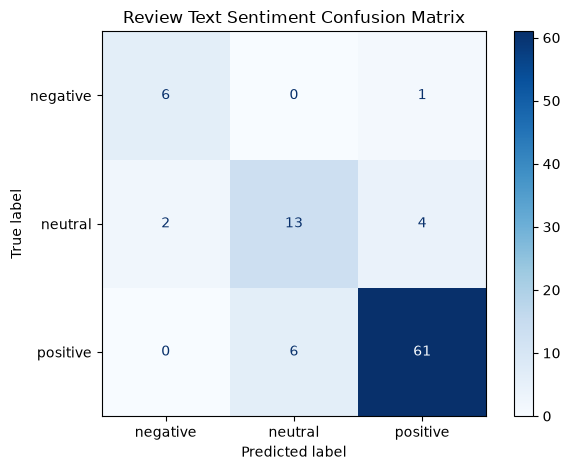

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define the order of sentiment classes for consistent interpretation.
labels = ["negative", "neutral", "positive"]

# Compare actual and predicted sentiment classes.
matrix = confusion_matrix(y_test, y_pred_test, labels=labels)

# Display the number of correct and incorrect predictions for each sentiment class.
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=labels
)
display_matrix.plot(cmap="Blues")
plt.title("Review Text Sentiment Confusion Matrix")
plt.tight_layout()
plt.show()

*Analysis and Interpretation of Results:*

The confusion matrix shows that the model correctly classified 80 out of 93 test reviews, consistent with the testing accuracy of 86.0%.

Overall, the confusion matrix indicates that the model distinguishes the sentiment classes reasonably well, although the relatively small number of negative reviews and the overlap between neutral and positive language remain important limitations.

---
## 7 Evaluation and Model Comparison

We report accuracy, precision, recall, F1, and the complete per-class classification report. Macro F1 is important because it gives equal weight to each sentiment class. We also compare the model with the majority-class baseline.

In [10]:
from sklearn.metrics import classification_report, precision_score, recall_score

logistic_accuracy = accuracy_score(y_test, y_pred_test)
logistic_precision = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
logistic_recall = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
logistic_macro_f1 = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

print("=== Logistic Regression Test Metrics ===")
print(f"Accuracy:        {logistic_accuracy:.3f}")
print(f"Macro Precision: {logistic_precision:.3f}")
print(f"Macro Recall:    {logistic_recall:.3f}")
print(f"Macro F1:        {logistic_macro_f1:.3f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_test, zero_division=0))

=== Logistic Regression Test Metrics ===
Accuracy:        0.860
Macro Precision: 0.786
Macro Recall:    0.817
Macro F1:        0.801

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.75      0.86      0.80         7
     neutral       0.68      0.68      0.68        19
    positive       0.92      0.91      0.92        67

    accuracy                           0.86        93
   macro avg       0.79      0.82      0.80        93
weighted avg       0.86      0.86      0.86        93



*Analysis and Interpretation of Results:*

The Logistic Regression model achieved an overall accuracy of 86.0% on the test data. 
The macro precision, recall, and F1-score were 78.6%, 81.7%, and 80.1%, respectively. 
The macro F1-score indicates that the model maintains reasonably good performance across the three sentiment classes rather than relying only on the majority class.

However further investigation indicates that the model performed best on positive reviews, achieving an F1-score of 0.92, with 92% precision and 91% recall. The negative class achieved an F1-score of 0.80, while the neutral class had the lowest F1-score of 0.68. This suggests that neutral reviews are comparatively more difficult for the model to distinguish from positive or negative reviews.

the results indicate good classification performance, particularly compared with the majority-class baseline. However, the smaller number of negative reviews and the lower performance on the neutral class should be considered when interpreting the results.


                        Model  Accuracy  Macro F1
0           Majority Baseline      0.72     0.279
1  TF-IDF Logistic Regression      0.86     0.801


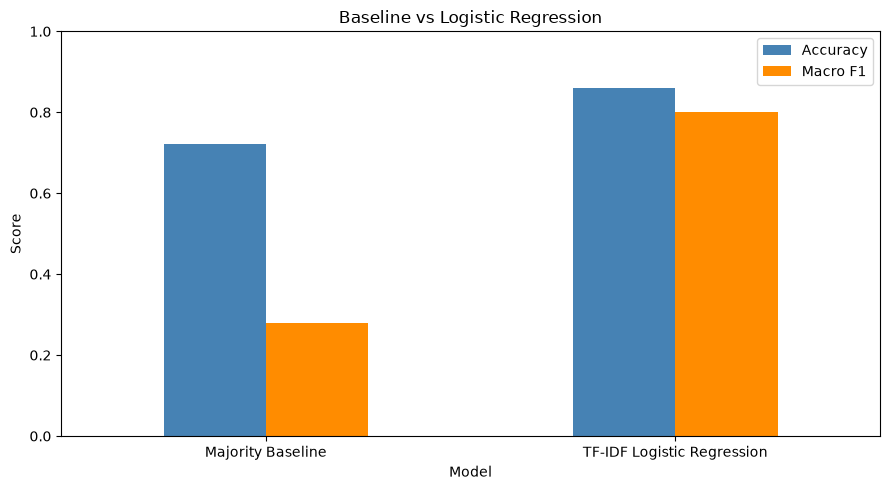

In [11]:
# Compare the baseline and Logistic Regression models using accuracy and macro F1-score.
# Macro F1 is particularly useful because it gives equal importance to each sentiment class.
comparison = pd.DataFrame({
    "Model": ["Majority Baseline", "TF-IDF Logistic Regression"],
    "Accuracy": [baseline_accuracy, logistic_accuracy],
    "Macro F1": [baseline_macro_f1, logistic_macro_f1]
})

print(comparison.round(3))

# Visualize the performance difference between the two models.
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5),
    color=["steelblue", "darkorange"]
)
plt.title("Baseline vs Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Analysis and Interpretation of Results:*

The TF-IDF Logistic Regression model substantially outperformed the majority-class baseline. Accuracy increased from 72.0% for the baseline to 86.0% for Logistic Regression, representing a 14 percentage-point improvement.

The improvement in Macro F1 is even more substantial, increasing from 0.279 to 0.801. This indicates that the Logistic Regression model provides much better classification across all three sentiment classes, rather than simply predicting the majority positive class.

Overall, the comparison demonstrates that incorporating TF-IDF text features and engineered review features provides considerably more useful sentiment predictions than a majority-class strategy.

### 7.2 Actual and Predicted Sentiment Distribution

This chart compares the number of actual weak labels with the model predictions in the test set.

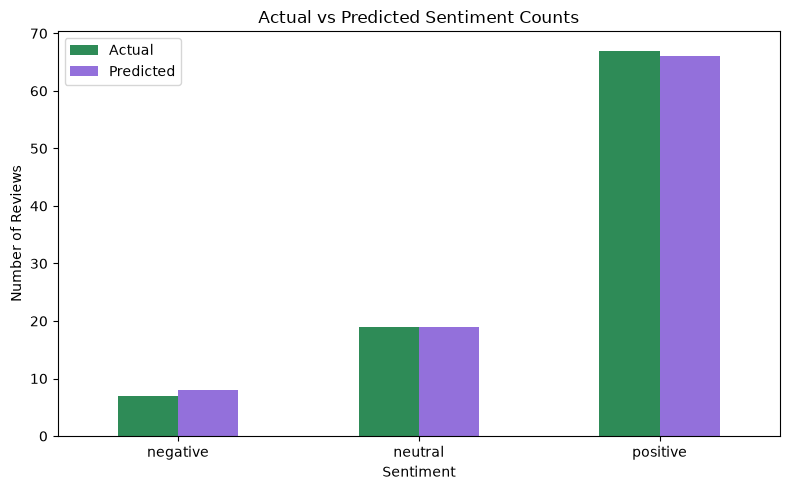

In [12]:
# Compare the number of actual and predicted observations in each sentiment class.
distribution_comparison = pd.DataFrame({
    "Actual": y_test.value_counts(),
    "Predicted": pd.Series(y_pred_test).value_counts()
}).fillna(0).reindex(labels)

# Visualize whether the model's predicted class distribution is similar to the actual distribution.
distribution_comparison.plot(
    kind="bar",
    figsize=(8, 5),
    color=["seagreen", "mediumpurple"]
)
plt.title("Actual vs Predicted Sentiment Counts")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Analysis and Interpretation of Results:*

The predicted sentiment distribution is very similar to the actual distribution in the test set.

The small differences between the actual and predicted counts suggest that the model does not substantially over-predict or under-predict any particular sentiment class. However, this comparison evaluates the overall class distribution rather than individual predictions, so it should be interpreted alongside the confusion matrix and classification metrics.

---
## 8 Making Live Review Predictions

For a new review, we calculate the same three numeric features and let the trained pipeline predict sentiment. No star rating is supplied.

In [15]:
def prepare_new_reviews(reviews):
# Create a DataFrame with the same columns used during training.
    new_data = pd.DataFrame({"original_review": reviews})
    new_data["clean_review"] = new_data["original_review"]
    new_data["clean_review"] = (
        new_data["clean_review"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# Recreate the numerical features required by the trained model
    word_count = new_data["clean_review"].str.split().str.len().clip(lower=1)
    character_count = new_data["clean_review"].str.len()
    unique_word_count = new_data["clean_review"].apply(lambda text: len(set(text.split())))

# Calculate the "average word length", "lexical diversity", and "exclamation density" using the original review text.

    new_data["average_word_length"] = character_count / word_count
    new_data["lexical_diversity"] = unique_word_count / word_count
    exclamation_count = new_data["original_review"].fillna("").str.count("!")
    new_data["exclamation_density"] = exclamation_count / word_count
    return new_data[["clean_review"] + numeric_features]

# Test the trained model on previously unseen sample reviews.
sample_reviews = [
    "The sound quality is excellent and I love the battery life",
    "The earbuds stopped working and the quality is terrible",
    "The product is okay and works as expected"
]

# Generate sentiment predictions for the new reviews.
sample_features = prepare_new_reviews(sample_reviews)
sample_predictions = sentiment_model.predict(sample_features)

# Display each review alongside its predicted sentiment.
prediction_results = pd.DataFrame({
    "Review": sample_reviews,
    "Predicted Sentiment": sample_predictions
})

prediction_results

,Review,Predicted Sentiment
0,The sound quality is excellent and I love the ...,positive
1,The earbuds stopped working and the quality is...,positive
2,The product is okay and works as expected,positive


*Analysis and Interpretation of Results:*

The model correctly identified the first review, which expresses strong satisfaction with sound quality and battery life, as positive. The third review was also classified as positive, reflecting its generally favorable description of the product.

However, the second review, which contains clearly negative expressions such as the product having stopped working and poor quality, was also classified as positive. This demonstrates that the model can make incorrect predictions for individual reviews despite achieving 86% overall test accuracy. Such errors may occur because the model was trained using a relatively small dataset and rule-based sentiment labels, and because individual words or phrases may not always capture the full context of a review.

Overall, this example demonstrates both the practical use of the trained sentiment classifier and the importance of evaluating model predictions critically rather than relying solely on aggregate performance metrics.


---
## Summary and Key Takeaways

1. The project uses the supplied AirPods dataset for the E-Commerce sentiment track.
2. `review_rating` and product metadata are excluded from the model.
3. Simple text rules create weak demonstration labels because the source CSV has no sentiment target.
4. Pandas creates average word length, lexical diversity, and exclamation density as interaction features.
5. TF-IDF converts written reviews into numerical word features.
6. The notebook uses the required 80/20 split and Scikit-Learn Logistic Regression.
7. Evaluation includes accuracy, macro precision, macro recall, macro F1, a classification report, and a confusion matrix.

### Limitation
1. The model was trained on 465 unique reviews. A larger and more diverse dataset could further improve its generalization to different writing styles and sentiment expressions.
2. The preprocessing captures basic text patterns but may not fully account for spelling variations, slang, emojis, sarcasm, negation, and mixed English–Roman Urdu expressions.
3. The reported scores measure how well Logistic Regression reproduces the simple word-list labels. They do not prove agreement with human sentiment judgment. A future version can replace the weak labels with manually reviewed text labels without adding star ratings as model inputs.